# Empirical Financial Time-Series Case Study

Can a parsimonious conditional-mean and conditional-variance model describe the main statistical features of daily market returns and produce sensible short-horizon forecasts?

This is one empirical study, not a search for trading alpha. We construct returns from prices, describe their distribution and dependence, estimate a small mean-model candidate set, diagnose remaining variance dynamics, and evaluate frozen-parameter forecasts against simple benchmarks. Earlier notebooks provide the theory; the emphasis here is the evidence and its limits.

In [1]:
from pathlib import Path
import sys
repository = Path.cwd()
if not (repository / "src" / "finstats").is_dir():
    repository = repository.parent
if not (repository / "src" / "finstats").is_dir():
    raise RuntimeError("Run from the repository root or notebooks directory")
sys.path.insert(0, str(repository / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display
from finstats.descriptive import (
    sample_mean, sample_variance, sample_standard_deviation,
    sample_skewness, sample_kurtosis,
)
plt.rcParams.update({
    "figure.figsize": (7,4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "font.size": 11, "axes.titlesize": 12,
    "legend.frameon": False, "lines.linewidth": 1.8,
})
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import pacf
from arch import arch_model
from finstats.nonparametric import qq_data
from finstats.timeseries.diagnostics import acf, ljung_box, mcleod_li, standardized_residuals
from finstats.timeseries.volatility import garch11_unconditional_variance, garch11_forecast
from finstats.timeseries.forecasting import forecast_rmse, forecast_mae, forecast_mse

# Styling only; calculations use the library functions introduced earlier.
def dependence_panel(ax, values, title):
    ax.vlines(np.arange(len(values)),0,values,color="C0",linewidth=1.2)
    ax.axhline(0,color="0.6",linewidth=.8)
    ax.set(xlabel="Lag",ylabel="Sample correlation",title=title)
from statsmodels.tsa.stattools import adfuller

## 1. Data and empirical question

Use the S&P 500 index closing price, 1 February 2017–16 November 2018, from a fixed local Yahoo Finance snapshot. This preserves the course's price-series workflow and closely follows its sample window. Provider rounding and the final holdout day can differ, so numerical replication of slide estimates is not claimed. Dataset provenance and checksum are in `data/README.md` and `data/manifest.json`.

The target is one-trading-observation-ahead return and innovation variance. The index excludes dividends; these are price-index log returns, not a total-return investment series. Date gaps for weekends and holidays remain gaps on the calendar, not missing returns to fill.

## 2. Data construction

From positive prices $P_t$, compute
$$r_t=100(\log P_t-\log P_{t-1}).$$
Units are percentage-point daily log returns. Verify sorted unique dates and finite positive closing prices. Differencing removes only the first price's undefined return; no interpolation, winsorization, or return deletion is applied. Training ends 2 November 2018; the fixed test window is 5–16 November 2018, ten trading observations. The first test return uses the preceding training price, which was already known.

For illustration, I connect the original prices with the constructed returns and mark the train/test boundary. All subsequent estimation, model selection, and distributional diagnostics use training returns only.

Prices: 2017-02-01–2018-11-16, n=454
Training returns: 2017-02-02–2018-11-02, n=443
Test returns: 2018-11-05–2018-11-16, n=10


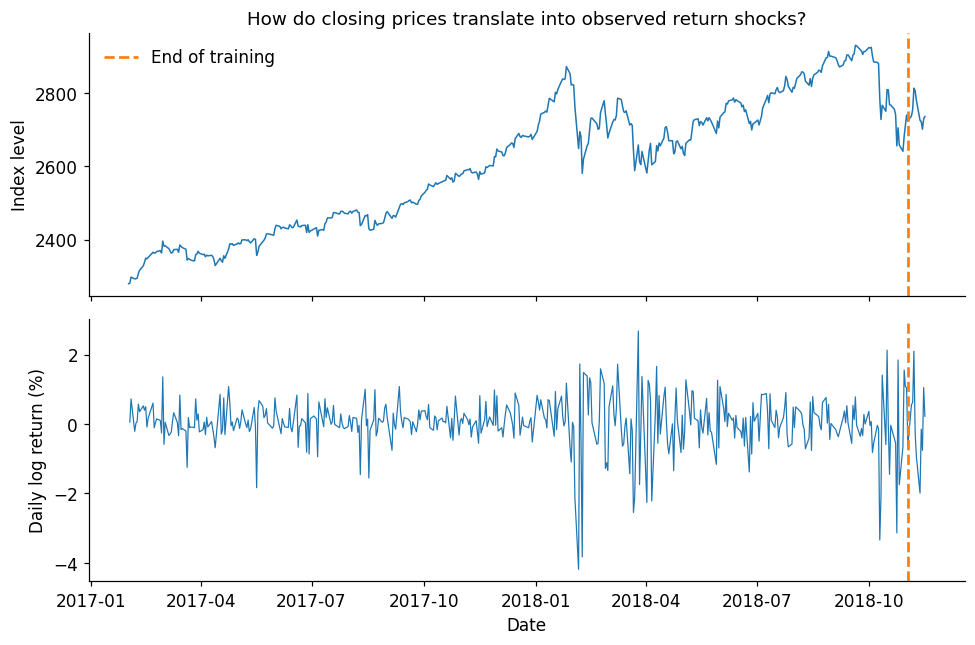

In [2]:
price_frame = pd.read_csv(repository / "data/sp500_prices_2017_2018.csv",parse_dates=["Date"])
assert price_frame.Date.is_monotonic_increasing and price_frame.Date.is_unique
assert np.isfinite(price_frame.Close).all() and (price_frame.Close>0).all()
prices = price_frame.set_index("Date").Close
returns = (100*np.log(prices).diff()).iloc[1:].rename("return")
assert np.isfinite(returns).all()
train = returns.loc[:"2018-11-02"]
test = returns.loc["2018-11-05":]
assert len(test)==10 and train.index.max()<test.index.min()
print(f"Prices: {prices.index.min().date()}–{prices.index.max().date()}, n={len(prices)}")
print(f"Training returns: {train.index.min().date()}–{train.index.max().date()}, n={len(train)}")
print(f"Test returns: {test.index.min().date()}–{test.index.max().date()}, n={len(test)}")
fig, axes = plt.subplots(2,1,figsize=(9,6),sharex=True)
axes[0].plot(prices.index,prices,linewidth=1);axes[0].set(ylabel="Index level",title="How do closing prices translate into observed return shocks?")
axes[1].plot(returns.index,returns,linewidth=.8);axes[1].set(xlabel="Date",ylabel="Daily log return (%)")
for ax in axes: ax.axvline(train.index.max(),color="C1",linestyle="--",label="End of training")
axes[0].legend();fig.tight_layout();plt.show()

## 3. Exploratory distribution analysis

Reuse Notebook 01's sample summaries and Notebook 04's Gaussian-reference diagnostics. Report raw kurtosis, whose Gaussian benchmark is three. The KDE bandwidth is SciPy's default Scott rule; it is a smoothing choice, not an estimated true density. Gaussian QQ departures describe this sample, not a proof of a particular heavy-tailed family.

For illustration, I compare the training histogram/KDE with a Gaussian reference and locate tail departures in the QQ plot. The sample mean and volatility remain estimates, not known population parameters.

,n,mean (%),SD (%),skewness,raw kurtosis
0,443,0.04013,0.73262,-1.3099,9.43115


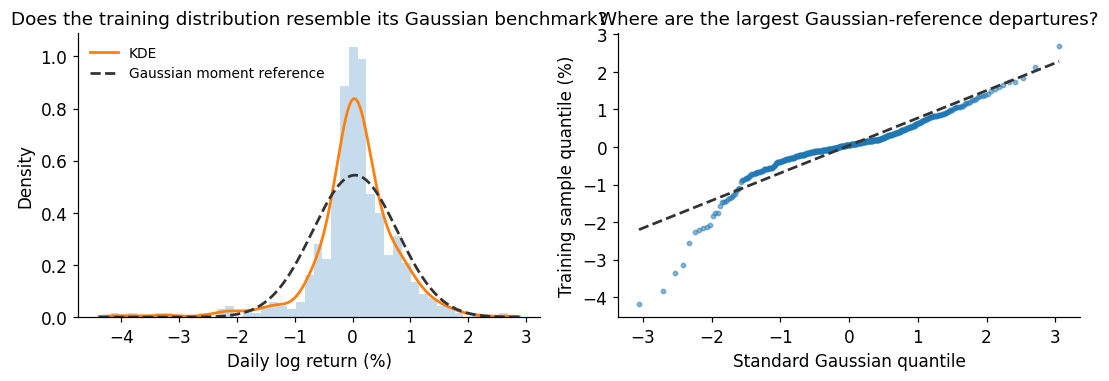

In [3]:
descriptive_table = pd.DataFrame([{"n":len(train),"mean (%)":sample_mean(train),"SD (%)":sample_standard_deviation(train),"skewness":sample_skewness(train),"raw kurtosis":sample_kurtosis(train)}])
display(descriptive_table.round(5))
train_mu, train_sd = sample_mean(train),sample_standard_deviation(train)
return_grid = np.linspace(train.min()-.2,train.max()+.2,801)
fig, axes = plt.subplots(1,2,figsize=(10,3.6))
axes[0].hist(train,bins=45,density=True,alpha=.25)
axes[0].plot(return_grid,stats.gaussian_kde(train)(return_grid),label="KDE")
axes[0].plot(return_grid,stats.norm.pdf(return_grid,loc=train_mu,scale=train_sd),"--",color="0.2",label="Gaussian moment reference")
axes[0].set(xlabel="Daily log return (%)",ylabel="Density",title="Does the training distribution resemble its Gaussian benchmark?");axes[0].legend(fontsize=9)
normal_quantiles, observed = qq_data(train)
axes[1].scatter(normal_quantiles,observed,s=8,alpha=.5)
axes[1].plot(normal_quantiles,train_mu+train_sd*normal_quantiles,"--",color="0.2")
axes[1].set(xlabel="Standard Gaussian quantile",ylabel="Training sample quantile (%)",title="Where are the largest Gaussian-reference departures?")
fig.tight_layout();plt.show()

## 4. Time-series dependence

Conditional mean $E_t[r_{t+1}]$ and conditional variance $\operatorname{Var}_t(r_{t+1})$ are distinct targets. An ACF of returns concerns linear signed co-movement; an ACF of squares concerns magnitude dependence.

For illustration, I compare training return ACF/PACF with squared-return ACF over 20 lags. Use the course-adjusted exploratory ACF; subsequent portmanteau tests use the production denominator-$T$ convention. Finite-sample spikes guide a small candidate set, not a deterministic model fingerprint.

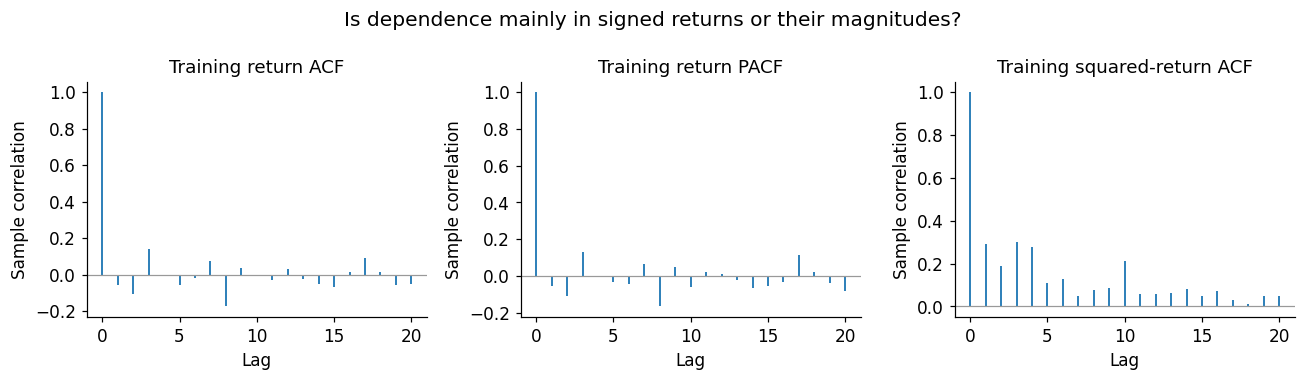

In [4]:
fig, axes = plt.subplots(1,3,figsize=(12,3.5))
dependence_panel(axes[0],acf(train,20),"Training return ACF")
dependence_panel(axes[1],pacf(train,nlags=20,method="ywm"),"Training return PACF")
dependence_panel(axes[2],acf(train**2,20),"Training squared-return ACF")
fig.suptitle("Is dependence mainly in signed returns or their magnitudes?")
fig.tight_layout();plt.show()

## 5. Stationarity assessment

Notebook 07 distinguishes the process from its observed history. I assess the training price level and returns using the unit-root diagnostic introduced in Notebook 08. The price-level regression includes a constant and linear trend, while the return regression includes a constant. ADF uses AIC to choose augmentation lags. The null is a unit root, and a rejection does not establish ergodicity or rule out changing variance. All subsequent model selection uses training returns.

In [5]:
stationarity_rows = []
training_log_prices = np.log(prices.loc[:train.index.max()]).to_numpy()
for label, values, specification in (("Log price", training_log_prices, "ct"), ("Return", train.to_numpy(), "c")):
    statistic, p_value, used_lag, nobs, critical_values, _ = adfuller(values, regression=specification, autolag="AIC")
    stationarity_rows.append({"Series":label, "Deterministic terms":specification, "ADF statistic":statistic, "p-value":p_value, "Augmentation lags":used_lag, "Observations":nobs})
display(pd.DataFrame(stationarity_rows))

,Series,Deterministic terms,ADF statistic,p-value,Augmentation lags,Observations
0,Log price,ct,-2.423998,3.669406e-01,9,434
1,Return,c,-8.533936,1.019976e-13,7,435


## 6. Conditional-mean model

Compare ARIMA(0,0,0), ARIMA(1,0,0), and ARIMA(2,0,0), each with a constant. They form a small nested subset of ARMA models: a constant mean, one return lag, or two lags. We do not difference returns again or perform an exhaustive search. This subset also permits joint AR–GARCH estimation in the mature volatility package without constructing a custom ARMA–GARCH optimizer.

Select the lowest-AIC Gaussian state-space fit on the common training sample, while also reporting BIC. A constant-mean result is allowed. Report coefficients, standard errors, and maximized log-likelihood. For stationary ARIMA fits, `const` is the unconditional mean; a recursion intercept is $(1-\sum_i\phi_i)\mu$. Later joint GARCH fitting can change these mean estimates.

For illustration, I compare fit and complexity within this candidate set before examining residual adequacy.

In [6]:
mean_models = {}
for p in [0,1,2]:
    fit = ARIMA(train.to_numpy(),order=(p,0,0),trend="c").fit()
    if not fit.mle_retvals.get("converged",True): raise RuntimeError(f"Mean candidate AR({p}) did not converge")
    mean_models[p] = fit
mean_comparison = pd.DataFrame([{"AR order":p,"log-likelihood":fit.llf,"AIC":fit.aic,"BIC":fit.bic} for p,fit in mean_models.items()])
display(mean_comparison.round(4))
selected_p = min(mean_models,key=lambda p:mean_models[p].aic)
mean_fit = mean_models[selected_p]
print(f"Selected mean within prespecified set: AR({selected_p})")
display(pd.DataFrame({"estimate":mean_fit.params,"standard error":mean_fit.bse},index=mean_fit.param_names).round(6))

,AR order,log-likelihood,AIC,BIC
0,0,-490.2620,984.5241,992.7112
1,1,-489.5801,985.1602,997.4409
2,2,-486.8856,981.7713,998.1455


Selected mean within prespecified set: AR(2)


,estimate,standard error
const,0.039977,0.035421
ar.L1,-0.061253,0.028317
ar.L2,-0.110139,0.031976
sigma2,0.527386,0.020434


## 7. Mean-model diagnostics

For illustration, I inspect the selected Gaussian mean fit's residual path and ACF, then Ljung–Box at 10 and 20 lags with $p$ fitted AR degrees of freedom deducted. Exclude the first two residuals from all subsequent preliminary diagnostics to keep a common presample span. Failure to reject does not prove independence; rejection is evidence that this deliberately small mean candidate set may leave structure unexplained.

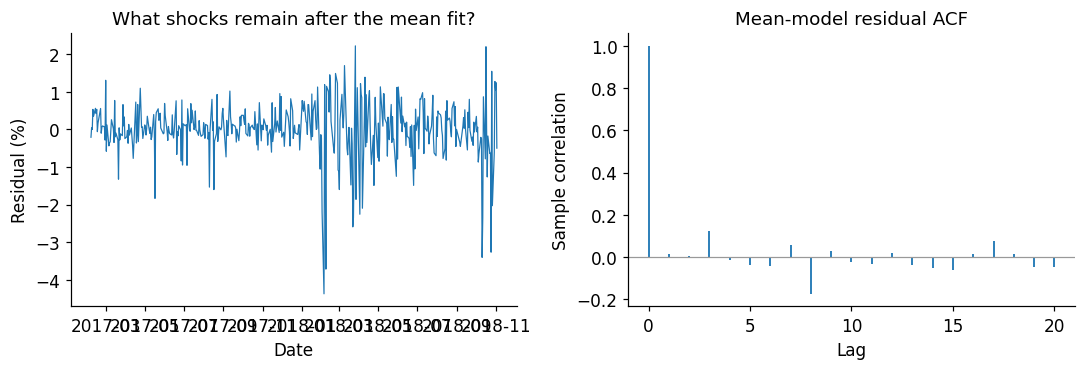

,statistic,p_value,df,lags,nobs
0,24.064047,0.002236,8,10,441
1,33.256125,0.015538,18,20,441


In [7]:
mean_residuals = np.asarray(mean_fit.resid)[2:]
residual_dates = train.index[2:]
fig, axes = plt.subplots(1,2,figsize=(10,3.5))
axes[0].plot(residual_dates,mean_residuals,linewidth=.8);axes[0].set(xlabel="Date",ylabel="Residual (%)",title="What shocks remain after the mean fit?")
dependence_panel(axes[1],acf(mean_residuals,20,adjusted=False),"Mean-model residual ACF")
fig.tight_layout();plt.show()
mean_diagnostics = pd.DataFrame([ljung_box(mean_residuals,h,model_df=selected_p) for h in [10,20]])
display(mean_diagnostics.round(6))

## 8. ARCH effects

For illustration, I inspect squared mean-model residuals and apply the McLeod–Li portmanteau screen from Notebook 08. Evidence of squared dependence justifies investigating a conditional-variance model; it does not identify GARCH(1,1) uniquely. Mean and squared diagnostics test different restrictions.

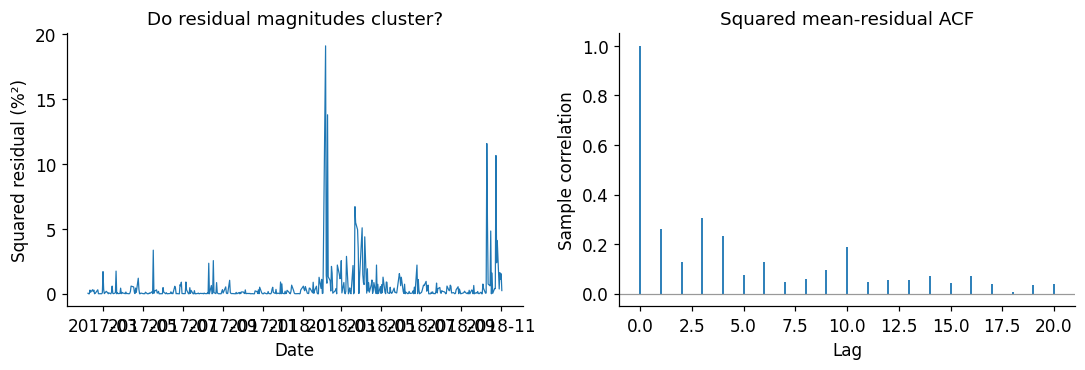

,statistic,p_value,df,lags,nobs
0,135.882709,0.0,10,10,441
1,147.520607,0.0,20,20,441


Squared-residual screen finds evidence at 5%: True


In [8]:
fig, axes = plt.subplots(1,2,figsize=(10,3.5))
axes[0].plot(residual_dates,mean_residuals**2,linewidth=.8);axes[0].set(xlabel="Date",ylabel="Squared residual (%²)",title="Do residual magnitudes cluster?")
dependence_panel(axes[1],acf(mean_residuals**2,20,adjusted=False),"Squared mean-residual ACF")
fig.tight_layout();plt.show()
arch_diagnostics = pd.DataFrame([mcleod_li(mean_residuals,h) for h in [10,20]])
display(arch_diagnostics.round(6))
print("Squared-residual screen finds evidence at 5%:",bool((arch_diagnostics.p_value<.05).any()))

## 9. GARCH(1,1)

Retain the selected mean order and estimate it jointly with
$$\sigma_t^2=\omega+\alpha a_{t-1}^2+\beta\sigma_{t-1}^2.$$
Gaussian estimation begins the comparison. The `arch` mean intercept is the recursion intercept; its AR coefficients map directly to lagged returns. Hold back the first two observations for every innovation fit, so their likelihoods use exactly the same observations. The package variance backcast is part of its initialization.

For illustration, I report joint estimates and robust SEs, persistence $\hat\alpha+\hat\beta$, and $\hat\omega/(1-\hat\alpha-\hat\beta)$ only when finite. Plot fitted conditional SD. All quantities are in percentage-return units, with variance in squared units; a near-unit persistence estimate makes the implied long-run moment sensitive.
A persistence estimate within $10^{-6}$ of one is treated as a numerical boundary fit, rather than converting optimizer roundoff into an enormous nominal long-run variance. Finite-horizon recursion remains available.

,estimate,robust SE
Const,0.108148,0.037485
return[1],-0.088610,0.063541
return[2],-0.045503,0.064931
omega,0.031620,0.015387
alpha[1],0.194925,0.094675
beta[1],0.756474,0.079572


Gaussian persistence=0.951398; long-run variance (%²)=0.6506009978102273


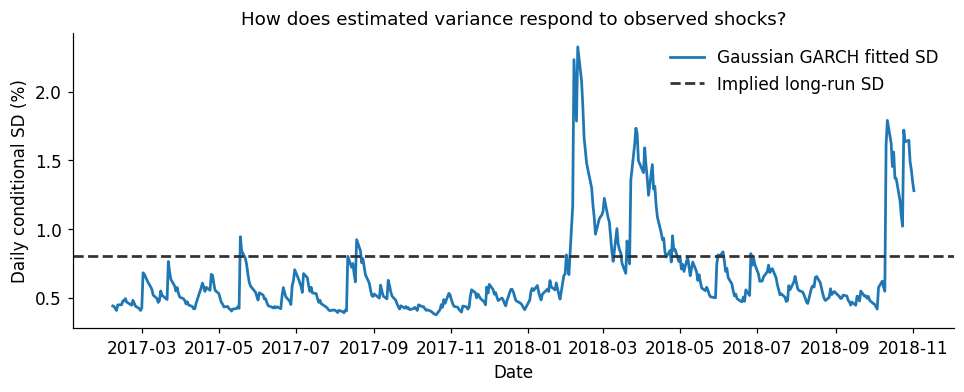

In [9]:
gaussian_fit = arch_model(train,mean="AR",lags=selected_p,vol="GARCH",p=1,q=1,dist="normal",rescale=False,hold_back=2).fit(disp="off",update_freq=0)
assert gaussian_fit.convergence_flag==0
display(pd.DataFrame({"estimate":gaussian_fit.params,"robust SE":gaussian_fit.std_err}).round(6))
gaussian_persistence = gaussian_fit.params["alpha[1]"]+gaussian_fit.params["beta[1]"]
gaussian_long_run = garch11_unconditional_variance(gaussian_fit.params["omega"],gaussian_fit.params["alpha[1]"],gaussian_fit.params["beta[1]"]) if gaussian_persistence < 1-1e-6 else np.nan
print(f"Gaussian persistence={gaussian_persistence:.6f}; long-run variance (%²)={gaussian_long_run}")
fig, ax = plt.subplots(figsize=(9,3.7))
ax.plot(train.index,gaussian_fit.conditional_volatility,label="Gaussian GARCH fitted SD")
if np.isfinite(gaussian_long_run): ax.axhline(np.sqrt(gaussian_long_run),color="0.2",linestyle="--",label="Implied long-run SD")
ax.set(xlabel="Date",ylabel="Daily conditional SD (%)",title="How does estimated variance respond to observed shocks?")
ax.legend();fig.tight_layout();plt.show()

## 10. Innovation distribution

Fit a Student-t innovation version with the same mean and variance equation and the same training observations. The innovations are standardized to variance one: $\nu_t=\sqrt{(d-2)/d}\,T_d$, $d>2$.

For illustration, I report likelihood/AIC/BIC and fitted degrees of freedom; inspect each model's standardized residuals against its own assumed quantiles. Select the lower AIC within this two-model comparison. A relative fit preference is evidence about conditional tails, not a declaration that the selected distribution is true.

,innovation,nobs,log-likelihood,AIC,BIC,df
0,Gaussian,441,-405.82369,823.64738,848.18165,NaN
1,Student-t,441,-367.51873,749.03747,777.66078,3.58446


Preferred within this comparison: Student-t


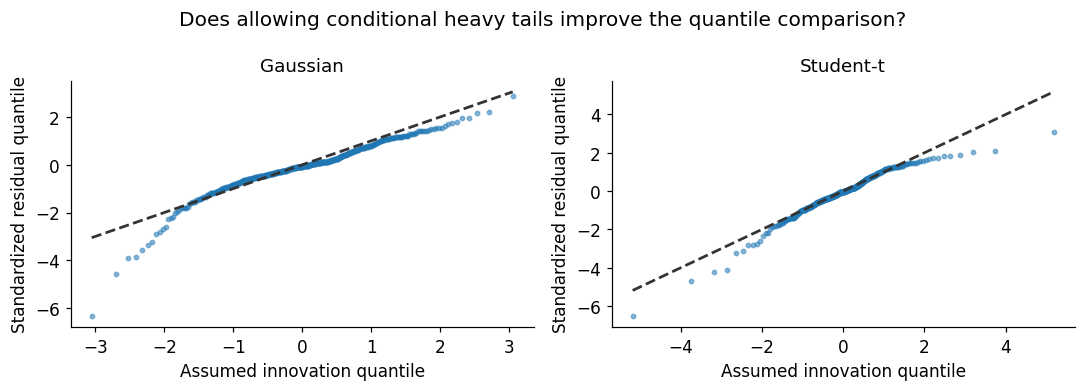

In [10]:
student_fit = arch_model(train,mean="AR",lags=selected_p,vol="GARCH",p=1,q=1,dist="t",rescale=False,hold_back=2).fit(disp="off",update_freq=0)
assert student_fit.convergence_flag==0
garch_comparison = pd.DataFrame([{"innovation":label,"nobs":fit.nobs,"log-likelihood":fit.loglikelihood,"AIC":fit.aic,"BIC":fit.bic,"df":fit.params.get("nu",np.nan)} for label,fit in [("Gaussian",gaussian_fit),("Student-t",student_fit)]])
display(garch_comparison.round(5))
final_fit = min([gaussian_fit,student_fit],key=lambda fit:fit.aic)
final_label = "Student-t" if final_fit is student_fit else "Gaussian"
print("Preferred within this comparison:",final_label)
fig, axes = plt.subplots(1,2,figsize=(10,3.6))
for ax,label,fit in [(axes[0],"Gaussian",gaussian_fit),(axes[1],"Student-t",student_fit)]:
    valid = np.isfinite(fit.resid)&np.isfinite(fit.conditional_volatility)
    standardized = standardized_residuals(np.asarray(fit.resid)[valid],np.asarray(fit.conditional_volatility)[valid])
    distribution = stats.norm if label=="Gaussian" else stats.t(fit.params["nu"],scale=np.sqrt((fit.params["nu"]-2)/fit.params["nu"]))
    theoretical, observed = qq_data(standardized,distribution)
    ax.scatter(theoretical,observed,s=8,alpha=.5);ax.plot(theoretical,theoretical,"--",color="0.2")
    ax.set(xlabel="Assumed innovation quantile",ylabel="Standardized residual quantile",title=label)
fig.suptitle("Does allowing conditional heavy tails improve the quantile comparison?")
fig.tight_layout();plt.show()

## 11. Final diagnostics

Convergence alone is insufficient. Diagnose the preferred fit's standardized path, its ACF and squared ACF, and its assumed-innovation QQ plot. Ljung–Box on standardized residuals remains approximate after joint fitting. A squared-residual portmanteau needs finite fourth moments for its conventional calibration: if fitted Student-t $d\le4$, show its statistic and descriptive sample ACF but suppress the nominal chi-squared p-value rather than treat it as reliable inference.

For illustration, I identify what structure remains unexplained and report final parameter estimates and persistence. A favorable diagnostic result is limited to the lags and sample examined. No claim of independence follows.

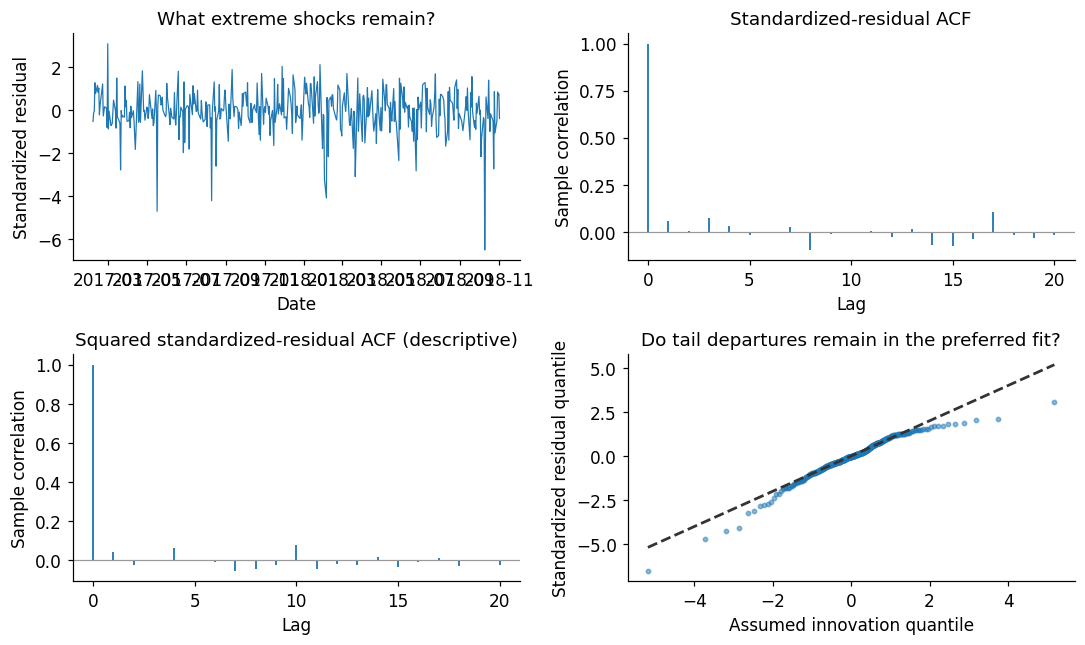

,series,statistic,p_value,df,lags,nobs
0,standardized,8.869158,0.353454,8,10,441
1,squared standardized,7.957191,NaN,10,10,441
2,standardized,20.900169,0.284480,18,20,441
3,squared standardized,10.734473,NaN,20,20,441


Squared-screen p-values omitted: fitted innovations have no finite fourth moment.


,estimate,robust SE
Const,0.082734,0.022325
return[1],-0.090393,0.053877
return[2],-0.039573,0.047385
omega,0.014336,0.014483
alpha[1],0.155984,0.095763
beta[1],0.844016,0.097968
nu,3.584462,0.729749


Preferred persistence=1.000000
No reliable finite long-run variance: the fit is at the numerical unit-persistence boundary.


In [11]:
valid_final = np.isfinite(final_fit.resid)&np.isfinite(final_fit.conditional_volatility)
final_residuals = np.asarray(final_fit.resid)[valid_final]
final_variances = np.asarray(final_fit.conditional_volatility)[valid_final]**2
final_standardized = standardized_residuals(final_residuals,np.sqrt(final_variances))
final_df = final_fit.params.get("nu",np.inf)
fig, axes = plt.subplots(2,2,figsize=(10,6))
axes[0,0].plot(train.index[valid_final],final_standardized,linewidth=.8);axes[0,0].set(xlabel="Date",ylabel="Standardized residual",title="What extreme shocks remain?")
dependence_panel(axes[0,1],acf(final_standardized,20,adjusted=False),"Standardized-residual ACF")
dependence_panel(axes[1,0],acf(final_standardized**2,20,adjusted=False),"Squared standardized-residual ACF (descriptive)")
reference = stats.norm if not np.isfinite(final_df) else stats.t(final_df,scale=np.sqrt((final_df-2)/final_df))
theoretical, observed = qq_data(final_standardized,reference)
axes[1,1].scatter(theoretical,observed,s=8,alpha=.5);axes[1,1].plot(theoretical,theoretical,"--",color="0.2")
axes[1,1].set(xlabel="Assumed innovation quantile",ylabel="Standardized residual quantile",title="Do tail departures remain in the preferred fit?")
fig.tight_layout();plt.show()
final_diagnostic_rows = []
for h in [10,20]:
    final_diagnostic_rows.append({"series":"standardized",**ljung_box(final_standardized,h,model_df=selected_p)})
    squared_screen = mcleod_li(final_standardized,h)
    if final_df<=4: squared_screen["p_value"]=np.nan
    final_diagnostic_rows.append({"series":"squared standardized",**squared_screen})
final_diagnostics = pd.DataFrame(final_diagnostic_rows)
display(final_diagnostics.round(6))
if final_df<=4: print("Squared-screen p-values omitted: fitted innovations have no finite fourth moment.")
display(pd.DataFrame({"estimate":final_fit.params,"robust SE":final_fit.std_err}).round(6))
final_params = final_fit.params
omega_hat, alpha_hat, beta_hat = final_params["omega"],final_params["alpha[1]"],final_params["beta[1]"]
final_persistence = alpha_hat+beta_hat
final_long_run = garch11_unconditional_variance(omega_hat,alpha_hat,beta_hat) if final_persistence < 1-1e-6 else np.nan
print(f"Preferred persistence={final_persistence:.6f}")
if np.isfinite(final_long_run):
    print(f"Implied finite long-run variance={final_long_run:.6f} (%²)")
else:
    print("No reliable finite long-run variance: the fit is at the numerical unit-persistence boundary.")

## 12. Out-of-sample mean forecasts

Freeze all fitted parameters at the training cutoff. For each test observation, forecast using only earlier observed returns, then reveal that observation and update the history. This produces sequential one-step forecasts rather than an unlabelled mixture of fixed-origin and rolling forecasts. No test observations enter selection or estimation.

Use the jointly estimated mean equation of the preferred variance model. Benchmark against zero and the fixed training mean. Compare RMSE/MAE, in percentage-point units. The ten-observation test is one short episode and cannot establish stable predictive superiority.

For illustration, I show the small estimated conditional mean alongside the realized returns and quantify its performance relative to simple benchmarks. The variance recursion is updated in the same loop, made explicit for the next section.

,forecast,RMSE (%),MAE (%)
0,Joint fitted mean,1.11537,0.88363
1,Zero return,1.08357,0.86301
2,Training mean,1.08252,0.86301


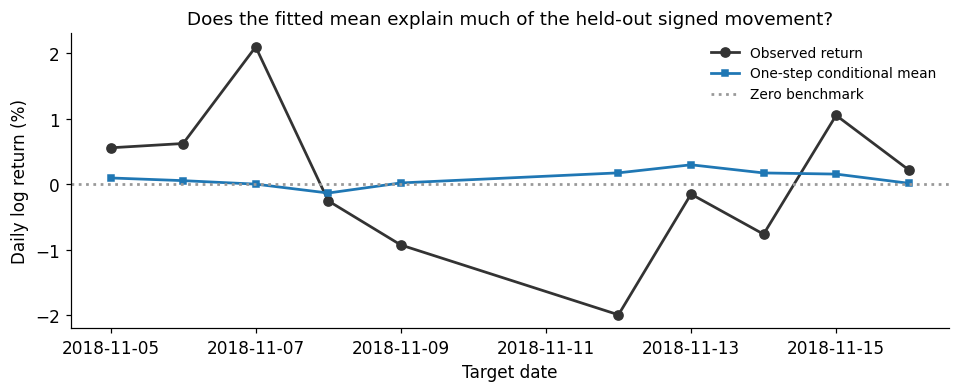

In [12]:
mean_parameter_names = final_fit.model.parameter_names()
mean_parameters = final_params.loc[mean_parameter_names].to_numpy()
mean_intercept, mean_ar = mean_parameters[0],mean_parameters[1:]
assert len(mean_ar)==selected_p
history = list(train.to_numpy())
previous_residual = final_residuals[-1]
previous_variance = final_variances[-1]
one_step_means, one_step_variances = [],[]
for observed in test.to_numpy():
    # Forecast first; the target observation has not been appended yet.
    prediction = mean_intercept+sum(coefficient*history[-lag] for lag,coefficient in enumerate(mean_ar,start=1))
    variance_prediction = garch11_forecast(previous_residual,previous_variance,omega_hat,alpha_hat,beta_hat,horizon=1)[0]
    one_step_means.append(prediction);one_step_variances.append(variance_prediction)
    # The realized target is now revealed for the NEXT forecast origin.
    previous_residual = observed-prediction
    previous_variance = variance_prediction
    history.append(observed)
one_step_means, one_step_variances = np.array(one_step_means),np.array(one_step_variances)
zero_forecast = np.zeros(len(test))
mean_benchmark = np.full(len(test),train_mu)
mean_evaluation = pd.DataFrame([{"forecast":label,"RMSE (%)":forecast_rmse(test,forecast),"MAE (%)":forecast_mae(test,forecast)} for label,forecast in [("Joint fitted mean",one_step_means),("Zero return",zero_forecast),("Training mean",mean_benchmark)]])
display(mean_evaluation.round(5))
fig, ax = plt.subplots(figsize=(9,3.7))
ax.plot(test.index,test,"o-",color="0.2",label="Observed return")
ax.plot(test.index,one_step_means,"s-",markersize=4,label="One-step conditional mean")
ax.axhline(0,color="0.6",linestyle=":",label="Zero benchmark")
ax.set(xlabel="Target date",ylabel="Daily log return (%)",title="Does the fitted mean explain much of the held-out signed movement?")
ax.legend(fontsize=9);fig.tight_layout();plt.show()

## 13. Out-of-sample volatility forecasts

The recursion forecasts **innovation variance**, not directly observed volatility. Evaluate it against $(r_t-\hat r_{t|t-1})^2$, a realized squared forecast error. It is a noisy proxy for latent innovation variance, not the true variance. The subtraction keeps the target aligned with the estimated mean equation; raw $r_t^2$ would be a related proxy when the mean is near zero.

For illustration, I plot one-step variance forecasts against the squared-error proxy and compare their MSE with a fixed training-variance benchmark. Plotting variances, not SDs against squared returns, keeps units consistent. Variance MSE has fourth-power percentage-point units. All parameters remain frozen; only observed past shocks update the state.

,variance forecast,proxy MSE (%⁴)
0,GARCH one-step,3.433896
1,Fixed training variance,3.318369


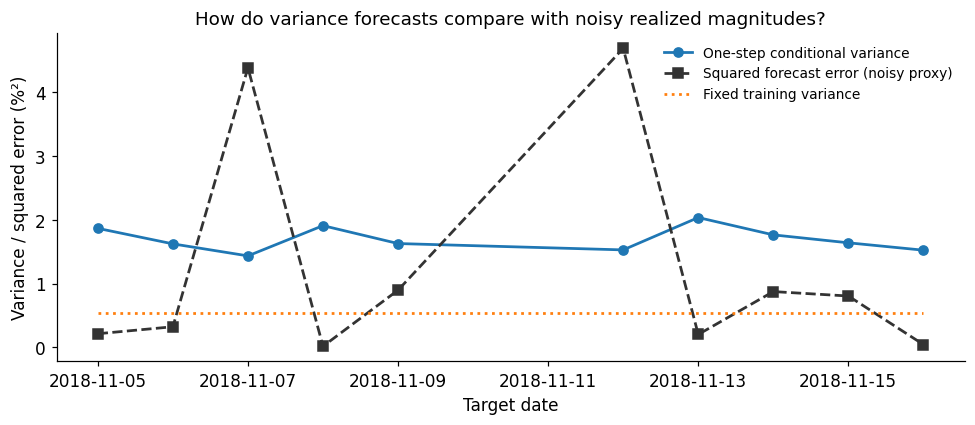

,observed return,mean forecast,variance forecast,squared-error proxy
Date,,,,
2018-11-05,0.55847,0.09845,1.86602,0.21162
2018-11-06,0.62398,0.05733,1.62230,0.32109
2018-11-07,2.09871,0.00423,1.43367,4.38684
2018-11-08,-0.25121,-0.13167,1.90865,0.01429
2018-11-09,-0.92416,0.02239,1.62750,0.89595
2018-11-12,-1.98982,0.17621,1.52772,4.69167
2018-11-13,-0.14830,0.29917,2.03558,0.20023
2018-11-14,-0.75962,0.17488,1.76363,0.87329
2018-11-15,1.05380,0.15727,1.63909,0.80378


In [13]:
realized_variance_proxy = (test.to_numpy()-one_step_means)**2
constant_variance = np.full(len(test),sample_variance(train))
variance_evaluation = pd.DataFrame([{"variance forecast":label,"proxy MSE (%⁴)":forecast_mse(realized_variance_proxy,forecast)} for label,forecast in [("GARCH one-step",one_step_variances),("Fixed training variance",constant_variance)]])
display(variance_evaluation.round(6))
fig, ax = plt.subplots(figsize=(9,4))
ax.plot(test.index,one_step_variances,"o-",label="One-step conditional variance")
ax.plot(test.index,realized_variance_proxy,"s--",color="0.2",label="Squared forecast error (noisy proxy)")
ax.plot(test.index,constant_variance,":",color="C1",label="Fixed training variance")
ax.set(xlabel="Target date",ylabel="Variance / squared error (%²)",title="How do variance forecasts compare with noisy realized magnitudes?")
ax.legend(fontsize=9)
fig.tight_layout();plt.show()
forecast_record = pd.DataFrame({"observed return":test,"mean forecast":one_step_means,"variance forecast":one_step_variances,"squared-error proxy":realized_variance_proxy})
display(forecast_record.round(5))

## 14. Final empirical interpretation

The results should be read as a conditional statistical description of this sample. The next cell assembles the actual fitted and holdout findings rather than assuming that every diagnostic passes or that the more complex model forecasts better.

In [14]:
mean_lb = mean_diagnostics.loc[mean_diagnostics.lags==20,"p_value"].iloc[0]
arch_p = arch_diagnostics.loc[arch_diagnostics.lags==20,"p_value"].iloc[0]
final_lb = final_diagnostics[(final_diagnostics.series=="standardized")&(final_diagnostics.lags==20)].p_value.iloc[0]
mean_rmse = mean_evaluation.set_index("forecast")["RMSE (%)"]
variance_mse = variance_evaluation.set_index("variance forecast")["proxy MSE (%⁴)"]
print(f"Mean dependence: AR({selected_p}) has lowest training AIC in the three-model set; preliminary residual Ljung–Box p={mean_lb:.4f} at lag 20.")
print(f"Volatility clustering: the squared preliminary residual screen has p={arch_p:.3g}; it motivates a variance model rather than identifying one uniquely.")
print(f"Variance persistence: {final_persistence:.6f}.")
if np.isfinite(final_long_run):
    print(f"Implied long-run variance={final_long_run:.6f} (%²); it is sensitive to persistence near one.")
else:
    print("The fit reaches the numerical unit-persistence boundary; a finite stationary long-run variance is not reported.")
print(f"Innovation comparison: {final_label} has lower AIC within the two candidates; Student-t df={student_fit.params['nu']:.3f}. This is evidence about conditional tail fit, not model truth.")
print(f"Holdout mean RMSE: fitted={mean_rmse['Joint fitted mean']:.4f}, zero={mean_rmse['Zero return']:.4f}, training mean={mean_rmse['Training mean']:.4f} (%).")
print(f"Holdout variance-proxy MSE: GARCH={variance_mse['GARCH one-step']:.4f}, fixed={variance_mse['Fixed training variance']:.4f} (%⁴).")
print(f"Remaining structure: preferred standardized-residual Ljung–Box p={final_lb:.4f} at lag 20. Its interpretation is approximate after fitting and limited to linear dependence.")
if final_df<=4:
    print("The preferred heavy-tailed innovation model has no finite fourth moment, so squared-residual ACFs remain descriptive and their nominal chi-squared p-values were omitted.")

Mean dependence: AR(2) has lowest training AIC in the three-model set; preliminary residual Ljung–Box p=0.0155 at lag 20.
Volatility clustering: the squared preliminary residual screen has p=1.87e-21; it motivates a variance model rather than identifying one uniquely.
Variance persistence: 1.000000.
The fit reaches the numerical unit-persistence boundary; a finite stationary long-run variance is not reported.
Innovation comparison: Student-t has lower AIC within the two candidates; Student-t df=3.584. This is evidence about conditional tail fit, not model truth.
Holdout mean RMSE: fitted=1.1154, zero=1.0836, training mean=1.0825 (%).
Holdout variance-proxy MSE: GARCH=3.4339, fixed=3.3184 (%⁴).
Remaining structure: preferred standardized-residual Ljung–Box p=0.2845 at lag 20. Its interpretation is approximate after fitting and limited to linear dependence.
The preferred heavy-tailed innovation model has no finite fourth moment, so squared-residual ACFs remain descriptive and their nomin

The short test period, noisy variance proxy, and near-unit persistence estimate limit the conclusions. A model can describe changing uncertainty better than a constant-variance benchmark without predicting return signs well. A lower AIC does not identify a true distribution, a large diagnostic p-value does not establish independence, and statistical fit does not imply profitable predictability or a causal explanation of market movements. Parameter uncertainty and structural change remain outside this compact study.

## 15. Repository synthesis

Notebook 04 supplies distributional descriptions and tail diagnostics. Notebook 07 explains stochastic processes, realized histories, stationarity and ergodicity. Notebook 08 supplies conditional-mean models, residual diagnostics, conditional-variance models and forecasting. This case study combines those tools on one observed financial series, without introducing another model class.

The results concern this finite history and the stated model assumptions. Good in-sample fit does not establish the true DGP, and a short holdout cannot establish general forecasting superiority.